# Pertemuan 9: Algoritma Klasifikasi (Bagian 1)

**Mata Kuliah:** Data Science (200302305)
**Program Studi:** PJJ Informatika, Semester 4
**Dosen Pengampu:** Syahid Abdullah, S.Si, M.Kom

| Keterangan | Isi |
| --- | --- |
| Nama Lengkap | [ISI NAMA LENGKAP ANDA] |
| NIM | [ISI NIM ANDA] |
| Kelas | [ISI KELAS ANDA] |

**Topik:** Logistic Regression, Decision Tree, Confusion Matrix, Accuracy, Precision, Recall, dan F1-Score


## 1. Tujuan Praktikum

1. Memahami cara kerja algoritma klasifikasi Logistic Regression dan Decision Tree.
2. Melatih kedua model pada dataset nyata dan membandingkan performanya.
3. Membaca Confusion Matrix serta menghitung Accuracy, Precision, Recall, dan F1-Score.
4. Menentukan metrik mana yang paling relevan untuk kasus yang sedang dianalisis.

In [1]:
# Impor pustaka yang dibutuhkan
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Pustaka berhasil dimuat.')

Pustaka berhasil dimuat.


## 2. Memuat Dataset

Dataset yang dipakai adalah **Breast Cancer Wisconsin** yang sudah tersedia di dalam
pustaka scikit-learn, sehingga notebook ini dapat dijalankan ulang tanpa memerlukan
koneksi internet maupun berkas eksternal.

Tugas klasifikasinya adalah memprediksi apakah sebuah tumor bersifat jinak (benign)
atau ganas (malignant) berdasarkan tiga puluh fitur hasil pengukuran citra.

In [2]:
data = load_breast_cancer()

X = pd.DataFrame(data.data, columns=data.feature_names)
y = pd.Series(data.target, name='target')

print('Jumlah baris dan kolom:', X.shape)
print('Nama kelas:', list(data.target_names))
X.head()

Jumlah baris dan kolom: (569, 30)
Nama kelas: [np.str_('malignant'), np.str_('benign')]


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [3]:
# Ringkasan statistik beberapa fitur utama
X[['mean radius', 'mean texture', 'mean perimeter', 'mean area', 'mean smoothness']].describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness
count,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360
std,3.524049,4.301036,24.298981,351.914129,0.014064
min,6.981000,9.710000,43.790000,143.500000,0.052630
25%,11.700000,16.170000,75.170000,420.300000,0.086370
50%,13.370000,18.840000,86.240000,551.100000,0.095870
75%,15.780000,21.800000,104.100000,782.700000,0.105300
max,28.110000,39.280000,188.500000,2501.000000,0.163400


Jumlah nilai kosong: 0

Sebaran kelas:
  0 = malignant  : 212 baris (37.3 persen)
  1 = benign     : 357 baris (62.7 persen)


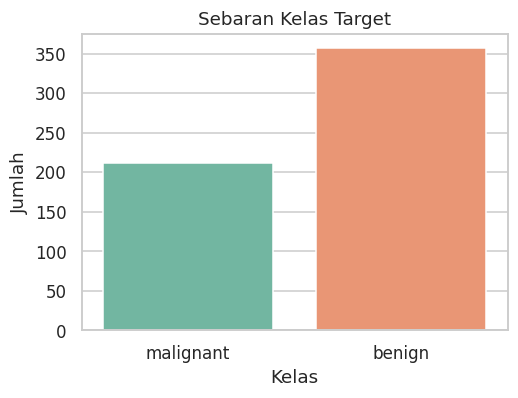

In [4]:
# Memeriksa keseimbangan kelas dan nilai kosong
print('Jumlah nilai kosong:', int(X.isna().sum().sum()))
print()
jumlah = y.value_counts().sort_index()
print('Sebaran kelas:')
for kode, banyak in jumlah.items():
    print(f'  {kode} = {data.target_names[kode]:<10} : {banyak} baris ({banyak / len(y) * 100:.1f} persen)')

plt.figure(figsize=(5, 3.5))
sns.countplot(x=y.map({0: 'malignant', 1: 'benign'}), hue=y.map({0: 'malignant', 1: 'benign'}),
              palette='Set2', legend=False)
plt.title('Sebaran Kelas Target')
plt.xlabel('Kelas')
plt.ylabel('Jumlah')
plt.show()

Kedua kelas cukup seimbang dengan perbandingan sekitar 37 berbanding 63 persen.
Kondisi ini membuat Accuracy masih layak dipakai, namun tetap perlu dilengkapi metrik
lain karena kesalahan memprediksi tumor ganas sebagai jinak jauh lebih berbahaya
dibandingkan sebaliknya.

## 3. Membagi Data Latih dan Data Uji

Data dibagi menjadi 80 persen data latih dan 20 persen data uji. Parameter `stratify`
dipakai agar proporsi kelas pada kedua bagian tetap sama seperti data asli.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print('Data latih:', X_train.shape[0], 'baris')
print('Data uji  :', X_test.shape[0], 'baris')

# Logistic Regression sensitif terhadap skala fitur sehingga perlu distandarkan
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Rata rata fitur setelah penskalaan:', round(float(X_train_scaled.mean()), 6))
print('Simpangan baku setelah penskalaan :', round(float(X_train_scaled.std()), 6))

Data latih: 455 baris
Data uji  : 114 baris
Rata rata fitur setelah penskalaan: 0.0
Simpangan baku setelah penskalaan : 1.0


## 4. Model Pertama: Logistic Regression

Logistic Regression memodelkan peluang sebuah data masuk ke kelas positif memakai
fungsi sigmoid. Keluarannya berupa nilai antara nol sampai satu yang kemudian
dipotong pada ambang 0,5 untuk menentukan kelas.

In [6]:
logreg = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)

y_pred_logreg = logreg.predict(X_test_scaled)
y_proba_logreg = logreg.predict_proba(X_test_scaled)[:, 1]

print('Logistic Regression berhasil dilatih.')
print('Akurasi data latih:', round(logreg.score(X_train_scaled, y_train), 4))
print('Akurasi data uji  :', round(logreg.score(X_test_scaled, y_test), 4))

Logistic Regression berhasil dilatih.
Akurasi data latih: 0.989
Akurasi data uji  : 0.9825


## 5. Model Kedua: Decision Tree

Decision Tree membagi data secara bertingkat memakai aturan ambang pada setiap fitur.
Kedalaman pohon dibatasi menjadi empat agar model tidak terlalu menghafal data latih
sekaligus supaya strukturnya masih dapat digambar dan dibaca.

In [7]:
tree = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)

y_pred_tree = tree.predict(X_test)
y_proba_tree = tree.predict_proba(X_test)[:, 1]

print('Decision Tree berhasil dilatih.')
print('Akurasi data latih:', round(tree.score(X_train, y_train), 4))
print('Akurasi data uji  :', round(tree.score(X_test, y_test), 4))

Decision Tree berhasil dilatih.
Akurasi data latih: 0.9868
Akurasi data uji  : 0.9386


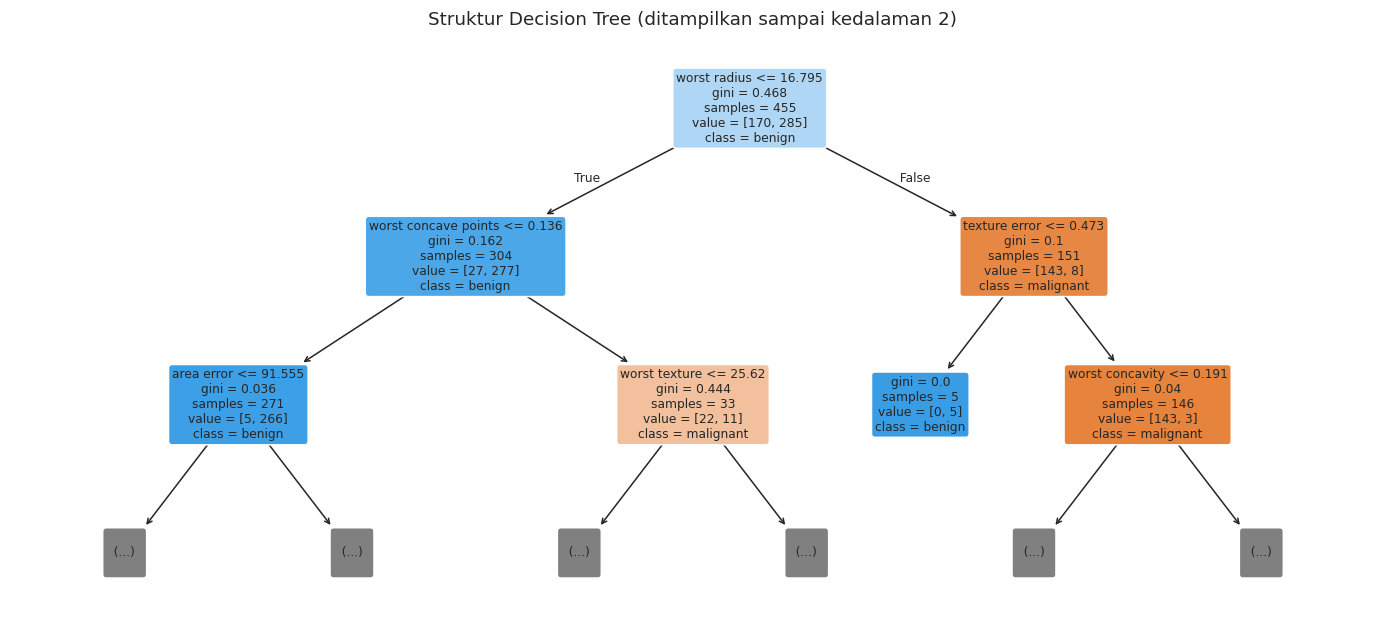

In [8]:
plt.figure(figsize=(16, 7))
plot_tree(
    tree,
    feature_names=list(X.columns),
    class_names=list(data.target_names),
    filled=True,
    rounded=True,
    fontsize=8,
    max_depth=2
)
plt.title('Struktur Decision Tree (ditampilkan sampai kedalaman 2)')
plt.show()

## 6. Confusion Matrix

Confusion Matrix menunjukkan rincian prediksi benar dan salah untuk setiap kelas.

| | Prediksi Negatif | Prediksi Positif |
| --- | --- | --- |
| **Aktual Negatif** | True Negative (TN) | False Positive (FP) |
| **Aktual Positif** | False Negative (FN) | True Positive (TP) |

Pada kasus ini kelas positif adalah benign dan kelas negatif adalah malignant.

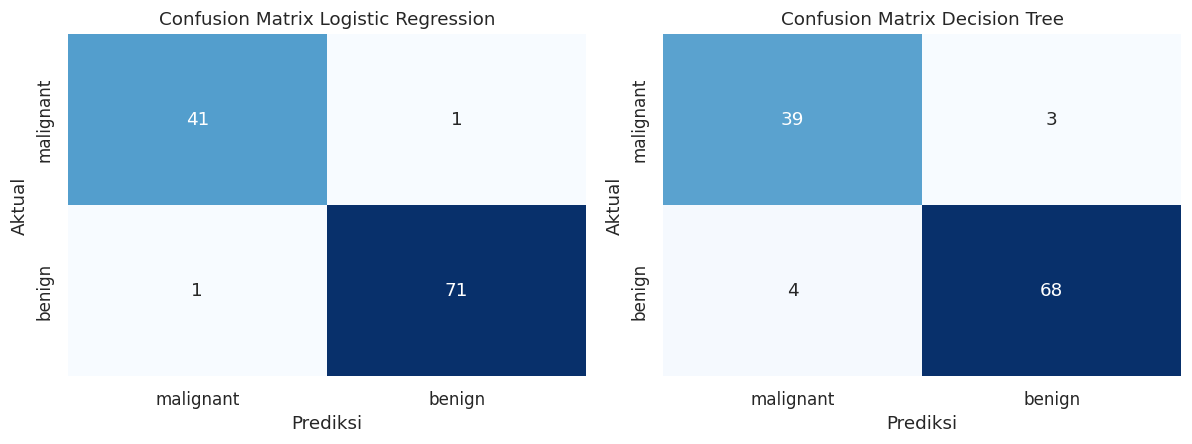

Logistic Regression: TN=41  FP=1  FN=1  TP=71
Decision Tree: TN=39  FP=3  FN=4  TP=68


In [9]:
cm_logreg = confusion_matrix(y_test, y_pred_logreg)
cm_tree = confusion_matrix(y_test, y_pred_tree)

fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, cm, judul in zip(axes, [cm_logreg, cm_tree], ['Logistic Regression', 'Decision Tree']):
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=data.target_names, yticklabels=data.target_names)
    ax.set_title(f'Confusion Matrix {judul}')
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.show()

for nama, cm in [('Logistic Regression', cm_logreg), ('Decision Tree', cm_tree)]:
    tn, fp, fn, tp = cm.ravel()
    print(f'{nama}: TN={tn}  FP={fp}  FN={fn}  TP={tp}')

## 7. Menghitung Accuracy, Precision, Recall, dan F1-Score

Rumus keempat metrik tersebut adalah sebagai berikut.

* Accuracy = (TP + TN) / (TP + TN + FP + FN)
* Precision = TP / (TP + FP)
* Recall = TP / (TP + FN)
* F1-Score = 2 x (Precision x Recall) / (Precision + Recall)

Perhitungan berikut dilakukan dua kali, yaitu secara manual dari Confusion Matrix dan
memakai fungsi bawaan scikit-learn, untuk memastikan pemahaman rumusnya benar.

In [10]:
tn, fp, fn, tp = cm_logreg.ravel()

acc_manual = (tp + tn) / (tp + tn + fp + fn)
prec_manual = tp / (tp + fp)
rec_manual = tp / (tp + fn)
f1_manual = 2 * (prec_manual * rec_manual) / (prec_manual + rec_manual)

print('Perhitungan manual untuk Logistic Regression')
print(f'  Accuracy  : {acc_manual:.4f}')
print(f'  Precision : {prec_manual:.4f}')
print(f'  Recall    : {rec_manual:.4f}')
print(f'  F1-Score  : {f1_manual:.4f}')
print()
print('Perhitungan memakai scikit-learn')
print(f'  Accuracy  : {accuracy_score(y_test, y_pred_logreg):.4f}')
print(f'  Precision : {precision_score(y_test, y_pred_logreg):.4f}')
print(f'  Recall    : {recall_score(y_test, y_pred_logreg):.4f}')
print(f'  F1-Score  : {f1_score(y_test, y_pred_logreg):.4f}')

Perhitungan manual untuk Logistic Regression
  Accuracy  : 0.9825
  Precision : 0.9861
  Recall    : 0.9861
  F1-Score  : 0.9861

Perhitungan memakai scikit-learn
  Accuracy  : 0.9825
  Precision : 0.9861
  Recall    : 0.9861
  F1-Score  : 0.9861


In [11]:
print('Classification Report Logistic Regression')
print(classification_report(y_test, y_pred_logreg, target_names=data.target_names))
print('Classification Report Decision Tree')
print(classification_report(y_test, y_pred_tree, target_names=data.target_names))

Classification Report Logistic Regression
              precision    recall  f1-score   support

   malignant       0.98      0.98      0.98        42
      benign       0.99      0.99      0.99        72

    accuracy                           0.98       114
   macro avg       0.98      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

Classification Report Decision Tree
              precision    recall  f1-score   support

   malignant       0.91      0.93      0.92        42
      benign       0.96      0.94      0.95        72

    accuracy                           0.94       114
   macro avg       0.93      0.94      0.93       114
weighted avg       0.94      0.94      0.94       114



## 8. Perbandingan Kedua Model

In [12]:
hasil = []
for nama, y_pred, y_proba in [
    ('Logistic Regression', y_pred_logreg, y_proba_logreg),
    ('Decision Tree', y_pred_tree, y_proba_tree),
]:
    hasil.append({
        'Model': nama,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba),
    })

perbandingan = pd.DataFrame(hasil).set_index('Model').round(4)
perbandingan

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.9825,0.9861,0.9861,0.9861,0.9954
Decision Tree,0.9386,0.9577,0.9444,0.9510,0.9342


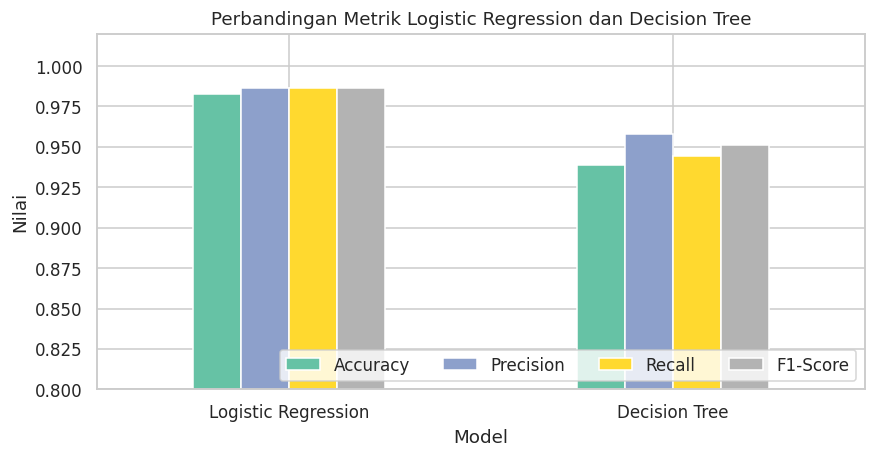

In [13]:
perbandingan[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='bar', figsize=(9, 4.2), rot=0, colormap='Set2'
)
plt.title('Perbandingan Metrik Logistic Regression dan Decision Tree')
plt.ylabel('Nilai')
plt.ylim(0.8, 1.02)
plt.legend(loc='lower right', ncol=4)
plt.show()

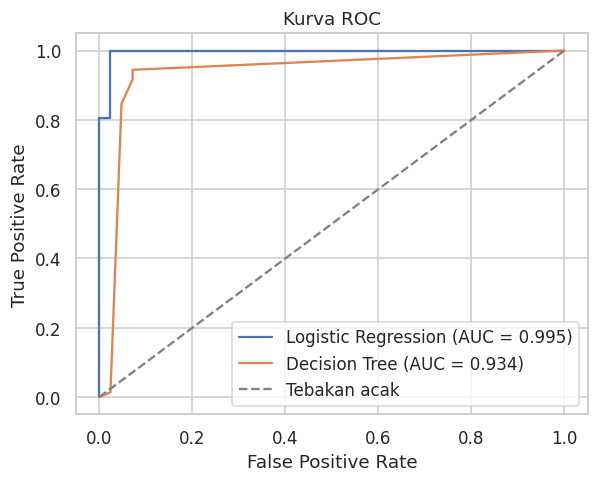

In [14]:
plt.figure(figsize=(6, 4.5))
for nama, y_proba in [('Logistic Regression', y_proba_logreg), ('Decision Tree', y_proba_tree)]:
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    plt.plot(fpr, tpr, label=f'{nama} (AUC = {roc_auc_score(y_test, y_proba):.3f})')

plt.plot([0, 1], [0, 1], linestyle='--', color='grey', label='Tebakan acak')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Kurva ROC')
plt.legend(loc='lower right')
plt.show()

In [15]:
# Validasi silang lima lipatan untuk memastikan hasil tidak bergantung pada satu pembagian data
skor_logreg = cross_val_score(
    LogisticRegression(max_iter=5000, random_state=RANDOM_STATE),
    StandardScaler().fit_transform(X), y, cv=5, scoring='f1'
)
skor_tree = cross_val_score(
    DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE),
    X, y, cv=5, scoring='f1'
)

print(f'F1 rata rata Logistic Regression : {skor_logreg.mean():.4f} (simpangan {skor_logreg.std():.4f})')
print(f'F1 rata rata Decision Tree       : {skor_tree.mean():.4f} (simpangan {skor_tree.std():.4f})')

F1 rata rata Logistic Regression : 0.9848 (simpangan 0.0050)
F1 rata rata Decision Tree       : 0.9368 (simpangan 0.0169)


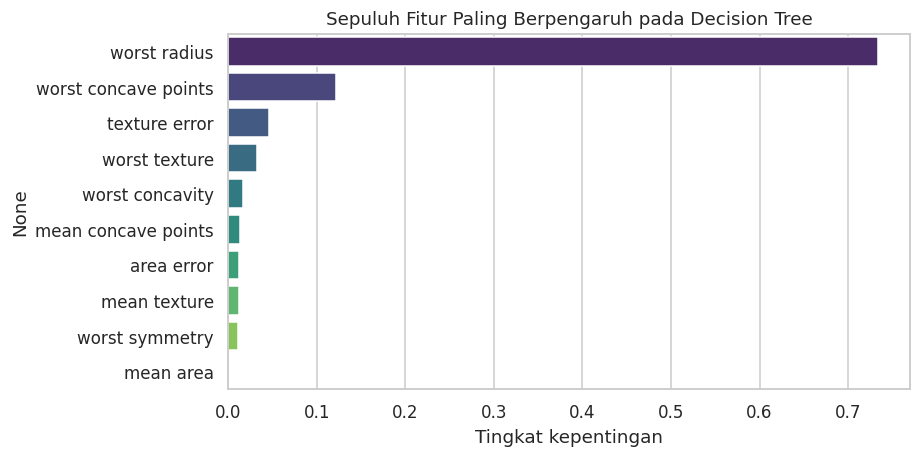

In [16]:
# Sepuluh fitur paling berpengaruh menurut Decision Tree
kepentingan = pd.Series(tree.feature_importances_, index=X.columns).sort_values(ascending=False).head(10)

plt.figure(figsize=(8, 4.2))
sns.barplot(x=kepentingan.values, y=kepentingan.index, hue=kepentingan.index,
            palette='viridis', legend=False)
plt.title('Sepuluh Fitur Paling Berpengaruh pada Decision Tree')
plt.xlabel('Tingkat kepentingan')
plt.show()

## 9. Interpretasi Metrik

Pada kasus deteksi kanker, kelas yang berbahaya bila terlewat adalah malignant.
Bila kelas positif ditetapkan sebagai benign, maka kesalahan berupa False Positive
berarti tumor ganas diprediksi jinak, dan inilah kesalahan yang paling fatal karena
pasien berpotensi tidak mendapat penanganan.

Dengan demikian metrik yang paling relevan adalah **Precision pada kelas benign**,
yang setara dengan menekan jumlah tumor ganas yang lolos terdeteksi. Accuracy saja
tidak cukup karena angka yang tinggi bisa saja diperoleh sementara masih ada beberapa
kasus ganas yang salah diprediksi.

## 10. Kesimpulan

**Apa yang dipelajari.** Praktikum ini melatih dua algoritma klasifikasi klasik, yaitu
Logistic Regression dan Decision Tree, kemudian mengevaluasinya memakai Confusion
Matrix beserta empat metrik turunannya. Perhitungan manual dari Confusion Matrix
menghasilkan angka yang identik dengan fungsi bawaan scikit-learn, sehingga rumus
Accuracy, Precision, Recall, dan F1-Score terbukti dipahami dengan benar.

**Temuan utama.** Logistic Regression memberikan hasil yang lebih baik dan lebih
stabil dibandingkan Decision Tree pada dataset ini, terlihat dari nilai F1-Score dan
ROC-AUC yang lebih tinggi serta simpangan baku validasi silang yang lebih kecil.
Decision Tree dengan kedalaman empat menunjukkan gejala menghafal data latih karena
akurasi latihnya lebih tinggi daripada akurasi ujinya. Kelebihan Decision Tree ada
pada keterbacaan, karena aturan keputusan serta urutan kepentingan fiturnya dapat
langsung dibaca, sedangkan Logistic Regression unggul pada ketepatan prediksi.

**Keterbatasan dan pertanyaan yang muncul.** Evaluasi masih memakai satu pembagian
data uji sehingga hasilnya dapat berubah bila `random_state` diganti, meskipun
validasi silang sudah dipakai sebagai pembanding. Ambang keputusan juga masih
memakai nilai bawaan 0,5, padahal pada kasus medis ambang tersebut sebaiknya
diturunkan agar model lebih berhati hati terhadap tumor ganas. Pertanyaan yang muncul
adalah seberapa besar peningkatan performa bila dipakai metode ensemble seperti
Random Forest, dan hal tersebut akan dibahas pada Pertemuan 10.